<a href="https://colab.research.google.com/github/pakchirav/Data-Science-Practicum/blob/main/DS_HW2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Healthcare Risk Factor Dataset


**Features**

Age: Patient’s age (in years).

Gender: Male / Female.

Medical Condition: Reported health condition (e.g., Diabetes, Hypertension, Asthma, Obesity, Healthy).

Glucose: Blood glucose level.

Blood Pressure: Blood pressure measurement.

BMI: Body Mass Index.

Oxygen Saturation: Blood oxygen saturation level.

LengthOfStay: Hospital length of stay (days).

Cholesterol: Cholesterol level.

Triglycerides: Triglyceride level.

HbA1c: Hemoglobin A1c (glycated hemoglobin).

Smoking: Smoking status (0 = Non-smoker, 1 = Smoker).

Alcohol: Alcohol consumption (0 = No, 1 = Yes).

Physical Activity: Physical activity (approx. hours/week).

Diet Score: Diet quality score (numeric).

Family History: Family medical history (0 = No, 1 = Yes).

Stress Level: Stress level (numeric scale).

Sleep Hours: Average sleep hours per day.

random_notes: Random notes (lorem / ipsum / ###).

noise_col: Noise column (unrelated random values).

###  Data Science Question : Which demographic and clinical risk most effectively differentiate between the five medical conditions?


In [108]:
import pandas as pd
data = pd.read_csv('dirty_v3_path.csv')
print(f'Missing values in percent:{data.isnull().any(axis=1).mean() *100}')

Missing values in percent:55.48333333333333


In [109]:
data.sample(10)

,Age,Gender,Medical Condition,Glucose,Blood Pressure,BMI,Oxygen Saturation,LengthOfStay,Cholesterol,Triglycerides,HbA1c,Smoking,Alcohol,Physical Activity,Diet Score,Family History,Stress Level,Sleep Hours,random_notes,noise_col
16453,71.0,Female,Arthritis,120.30,112.10,27.33,94.02,2,225.12,212.47,5.47,0,0,1.73,2.55,0,6.45,7.84,ipsum,14.003746
3800,53.0,NaN,NaN,150.92,135.17,23.54,99.01,6,194.18,130.55,10.01,0,1,4.32,3.63,0,5.38,7.65,??,-76.569988
21758,76.0,Female,NaN,127.34,174.38,30.96,93.55,2,219.06,213.98,6.15,0,0,2.85,2.05,1,4.20,5.48,ipsum,-140.338060
4127,64.0,Male,NaN,70.74,137.83,21.49,94.72,1,188.43,114.07,5.23,1,0,7.96,8.49,1,1.86,6.61,??,-58.098871
15254,50.0,Male,NaN,104.81,NaN,30.96,94.96,5,156.73,111.29,5.98,1,0,2.56,2.72,0,6.88,7.09,??,9.251497
5804,74.0,Female,Diabetes,176.16,130.16,32.91,92.93,6,232.78,143.80,9.88,0,0,4.79,2.47,1,6.11,6.28,###,-187.299731
280,20.0,Female,Healthy,61.46,121.65,26.85,95.61,2,171.03,119.32,5.07,0,0,7.24,5.28,0,1.41,9.28,??,-56.614686
2783,NaN,Male,Arthritis,118.80,133.83,22.83,99.60,3,203.91,200.22,6.11,0,0,2.42,2.24,1,4.73,8.06,lorem,-130.665305
8519,NaN,Male,Cancer,137.52,142.32,23.92,90.51,13,208.76,190.16,6.35,0,0,2.43,5.82,0,8.65,2.61,lorem,-7.740427
23890,88.0,NaN,Arthritis,98.70,131.55,24.22,95.86,5,194.88,155.14,5.77,0,0,3.31,5.18,1,2.43,6.52,###,-69.547835


In [110]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                25500 non-null  float64
 1   Gender             25500 non-null  object 
 2   Medical Condition  25500 non-null  object 
 3   Glucose            25500 non-null  float64
 4   Blood Pressure     25500 non-null  float64
 5   BMI                30000 non-null  float64
 6   Oxygen Saturation  30000 non-null  float64
 7   LengthOfStay       30000 non-null  int64  
 8   Cholesterol        30000 non-null  float64
 9   Triglycerides      30000 non-null  float64
 10  HbA1c              30000 non-null  float64
 11  Smoking            30000 non-null  int64  
 12  Alcohol            30000 non-null  int64  
 13  Physical Activity  30000 non-null  float64
 14  Diet Score         30000 non-null  float64
 15  Family History     30000 non-null  int64  
 16  Stress Level       300

I decide to drop 'random_notes' and 'noise_col' columns because they don't relate to my analysis.

In [111]:
data.drop(['random_notes', 'noise_col'], axis=1, inplace=True)

In [112]:
data.head(5)

,Age,Gender,Medical Condition,Glucose,Blood Pressure,BMI,Oxygen Saturation,LengthOfStay,Cholesterol,Triglycerides,HbA1c,Smoking,Alcohol,Physical Activity,Diet Score,Family History,Stress Level,Sleep Hours
0,46.0,Male,Diabetes,137.04,135.27,28.90,96.04,6,231.88,210.56,7.61,0,0,-0.20,3.54,0,5.07,6.05
1,22.0,Male,Healthy,71.58,113.27,26.29,97.54,2,165.57,129.41,4.91,0,0,8.12,5.90,0,5.87,7.72
2,50.0,NaN,Asthma,95.24,NaN,22.53,90.31,2,214.94,165.35,5.60,0,0,5.01,4.65,1,3.09,4.82
3,57.0,NaN,Obesity,NaN,130.53,38.47,96.60,5,197.71,182.13,6.92,0,0,3.16,3.37,0,3.01,5.33
4,66.0,Female,Hypertension,95.15,178.17,31.12,94.90,4,259.53,115.85,5.98,0,1,3.56,3.40,0,6.38,6.64


In [113]:
data['Smoking'] = data['Smoking'].astype('object')
data['Alcohol'] = data['Alcohol'].astype('object')
data['Family History'] = data['Family History'].astype('object')

In [114]:
data.describe(include=["int64", 'float64'])

,Age,Glucose,Blood Pressure,BMI,Oxygen Saturation,LengthOfStay,Cholesterol,Triglycerides,HbA1c,Physical Activity,Diet Score,Stress Level,Sleep Hours
count,25500.000000,25500.000000,25500.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,54.616784,123.622179,140.455337,28.476155,94.954992,4.414133,213.033891,176.837375,6.294377,3.803214,4.029654,5.917312,6.229836
std,15.973618,41.576943,21.077933,5.728804,3.736202,2.761536,33.519757,48.812827,1.320269,2.011729,1.817165,2.225057,1.187669
min,10.000000,20.320000,74.240000,7.670000,67.510000,1.000000,95.730000,-22.480000,3.280000,-3.680000,-1.750000,-2.440000,1.590000
25%,45.000000,96.280000,125.140000,24.590000,93.000000,3.000000,189.500000,141.280000,5.330000,2.350000,2.770000,4.370000,5.410000
50%,55.000000,110.500000,138.320000,28.050000,95.300000,4.000000,211.835000,173.365000,5.970000,3.590000,3.790000,5.900000,6.230000
75%,66.000000,136.610000,153.790000,31.810000,97.380000,5.000000,235.310000,208.630000,6.920000,5.060000,5.020000,7.440000,7.050000
max,89.000000,318.510000,226.380000,56.850000,110.070000,19.000000,358.370000,421.510000,12.360000,12.410000,12.060000,15.450000,10.350000


In [115]:
data.describe(include=['object']).drop(['Medical Condition'], axis=1)

,Gender,Smoking,Alcohol,Family History
count,25500,30000,30000,30000
unique,2,2,2,2
top,Female,0,0,0
freq,12865,21607,22844,16817


In [116]:
print(data['Medical Condition'].value_counts())

Medical Condition
Hypertension    7120
Diabetes        6417
Obesity         3857
Healthy         3039
Asthma          2037
Arthritis       1796
Cancer          1234
Name: count, dtype: int64


### Data Exploration

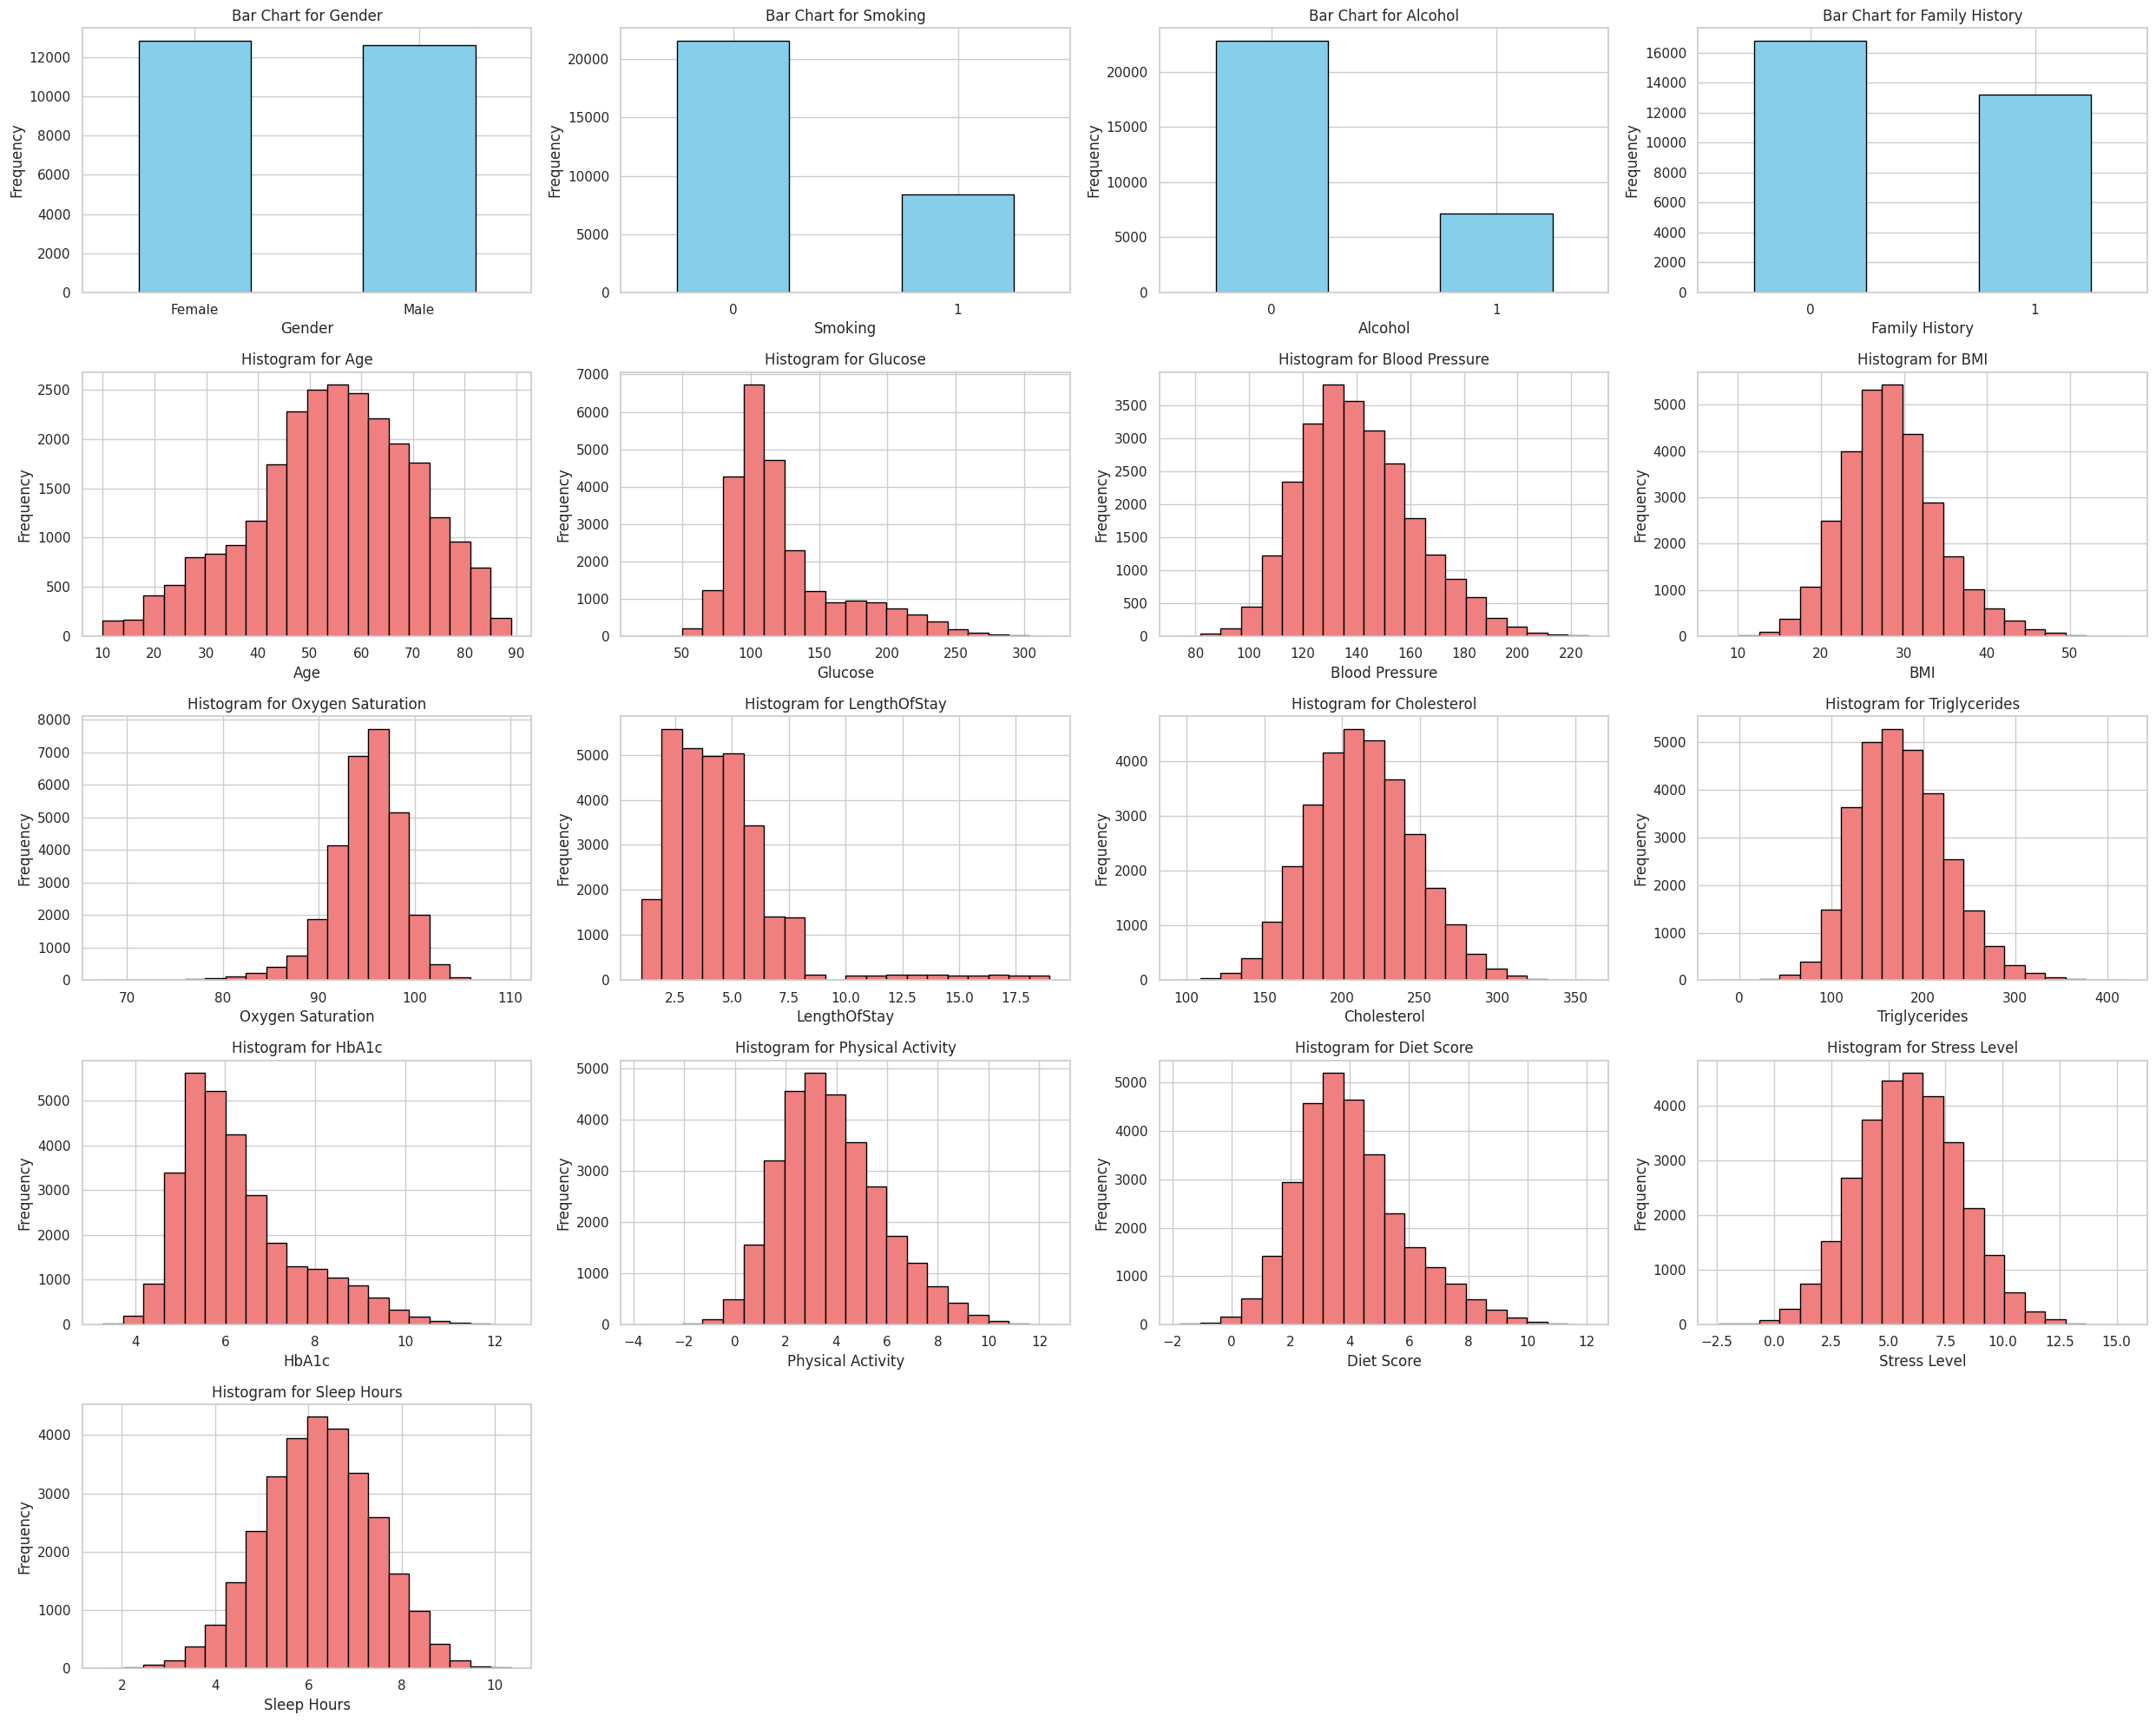

In [117]:
import seaborn as sns
import matplotlib.pyplot as plt

categorical_columns = ['Gender', 'Smoking', 'Alcohol', 'Family History']
numerical_columns = ['Age',	'Glucose', 'Blood Pressure',	'BMI',	'Oxygen Saturation',	'LengthOfStay',
                     'Cholesterol',	'Triglycerides',	'HbA1c',	'Physical Activity',	'Diet Score',	'Stress Level',
                     'Sleep Hours']

fig, axes = plt.subplots(nrows=5, ncols=4, figsize=(25, 20))

for i, column in enumerate(categorical_columns):
    row, col = divmod(i,4)
    data[column].value_counts().sort_index().plot(kind='bar', ax=axes[row, col], rot=0, color='skyblue',
                                                edgecolor='black')
    axes[row, col].set_title(f'Bar Chart for {column}')
    axes[row, col].set_xlabel(column)
    axes[row, col].set_ylabel('Frequency')
for i, column in enumerate(numerical_columns):
    row, col = divmod(i+len(categorical_columns),4)
    data[column].plot(kind='hist', bins=20, ax=axes[row, col], color='lightcoral', edgecolor='black')
    axes[row, col].set_title(f'Histogram for {column}')
    axes[row, col].set_xlabel(column)
    axes[row, col].set_ylabel('Frequency')

#Delete empty subplot
fig.delaxes(axes[4,1])
fig.delaxes(axes[4,2])
fig.delaxes(axes[4,3])
#Adjust layout
plt.tight_layout()
plt.show()


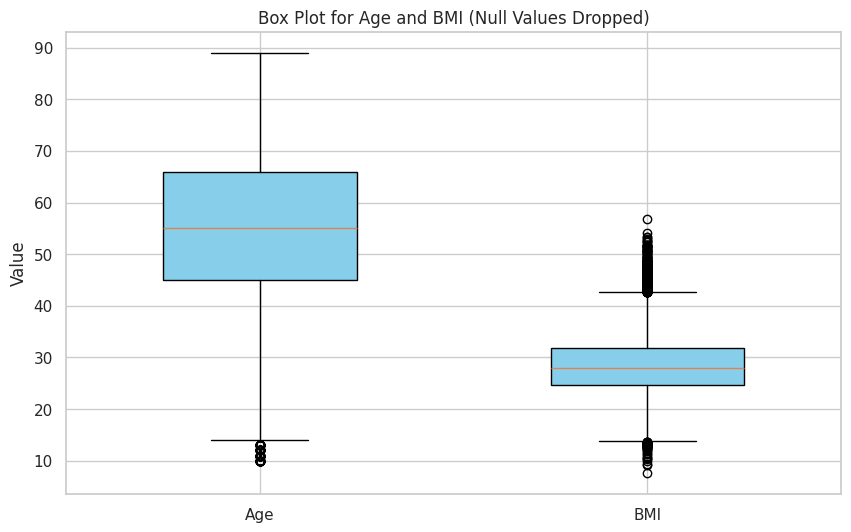

In [118]:
#print(data['BMI'].isnull().sum())
data_no_null_age = data.dropna(subset=['Age'])

plt.figure(figsize=(10, 6))
plt.boxplot(data_no_null_age['Age'], positions=[1], widths=0.5, patch_artist=True, boxprops=dict(facecolor=
                                                                                     'skyblue', color='black'))
plt.boxplot(data['BMI'], positions=[2], widths=0.5, patch_artist=True, boxprops=dict(facecolor=
                                                                                     'skyblue', color='black'))
plt.xticks([1,2], ['Age', 'BMI'])
plt.ylabel('Value')
plt.title('Box Plot for Age and BMI (Null Values Dropped)')
plt.show()

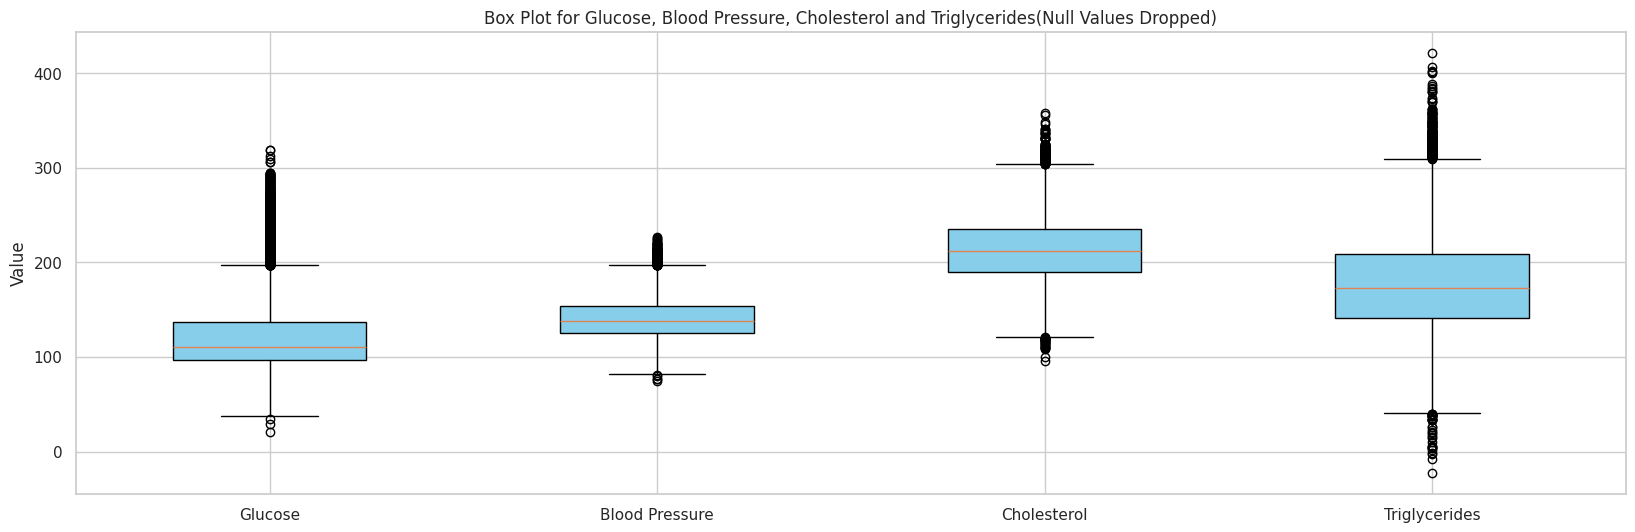

In [119]:
#print(data['Cholesterol'].isnull().sum())
data_no_null_glucose = data.dropna(subset=['Glucose'])
data_no_null_pressure = data.dropna(subset=['Blood Pressure'])

plt.figure(figsize=(20, 6))
plt.boxplot(data_no_null_glucose['Glucose'], positions=[1], widths=0.5, patch_artist=True, boxprops
            =dict(facecolor='skyblue', color='black'))
plt.boxplot(data_no_null_pressure['Blood Pressure'], positions=[2], widths=0.5, patch_artist=True,
            boxprops=dict(facecolor= 'skyblue', color='black'))
plt.boxplot(data['Cholesterol'], positions=[3], widths=0.5, patch_artist=True, boxprops=
            dict(facecolor= 'skyblue', color='black'))
plt.boxplot(data['Triglycerides'], positions=[4], widths=0.5, patch_artist=True, boxprops=
            dict(facecolor='skyblue', color='black'))
plt.xticks([1, 2, 3, 4], ['Glucose', 'Blood Pressure', 'Cholesterol', 'Triglycerides'])
plt.ylabel('Value')
plt.title('Box Plot for Glucose, Blood Pressure, Cholesterol and Triglycerides(Null Values Dropped)')
plt.show()

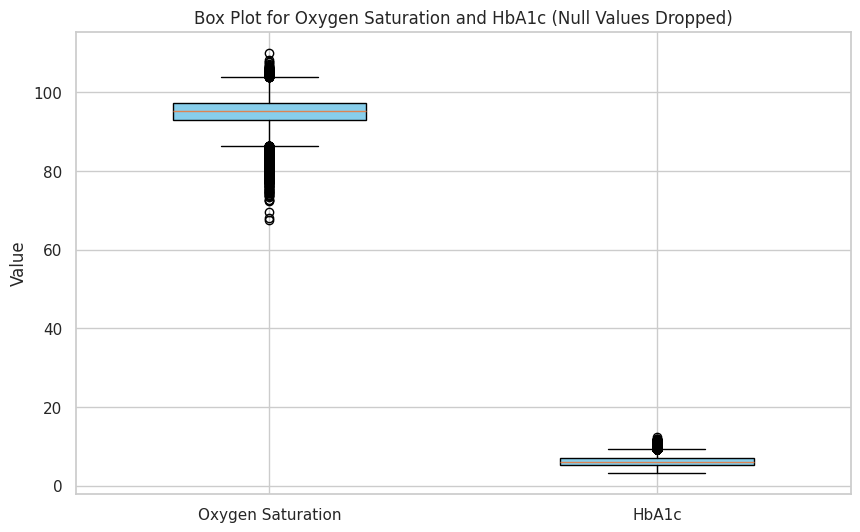

In [120]:
#print(data['HbA1c'].isnull().sum())
plt.figure(figsize=(10, 6))

plt.boxplot(data['Oxygen Saturation'], positions=[1], widths=0.5, patch_artist=True, boxprops=
            dict(facecolor= 'skyblue', color='black'))

plt.boxplot(data['HbA1c'], positions=[2], widths=0.5, patch_artist=True, boxprops=dict(facecolor=
                                                                                     'skyblue', color='black'))
plt.xticks([1, 2], ['Oxygen Saturation', 'HbA1c'])
plt.ylabel('Value')
plt.title('Box Plot for Oxygen Saturation and HbA1c (Null Values Dropped)')
plt.show()

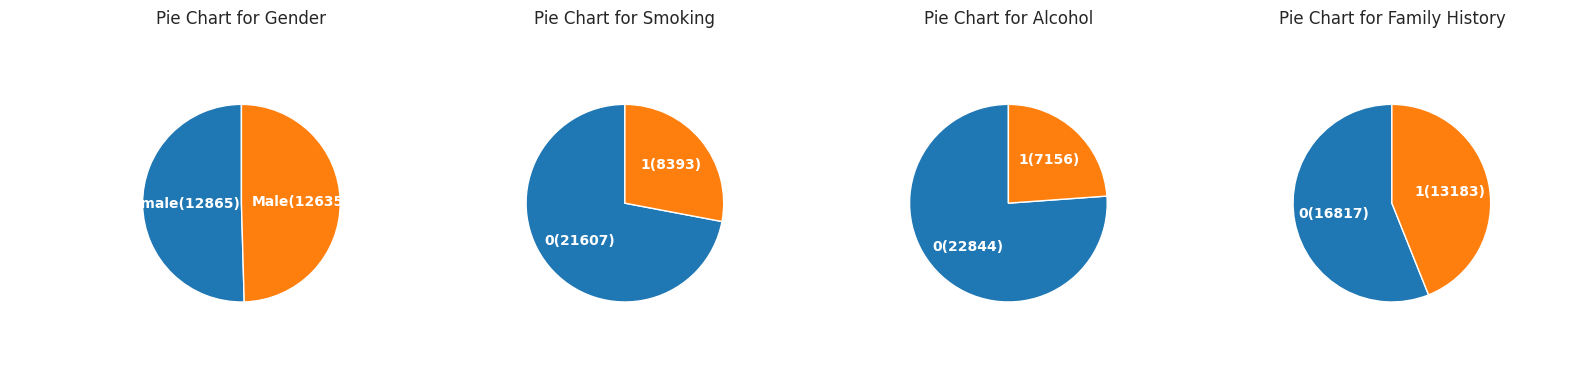

In [121]:
import math

n_rows = math.ceil(len(categorical_columns) / 4)
plt.figure(figsize=(16, n_rows*4))
color_palette = 'tab10'

for i, column in enumerate(categorical_columns):
    plt.subplot(n_rows, 4, i + 1)
    plt.title(f'Pie Chart for {column}')
    value_counts = data[column].value_counts()
    wedges, texts, autotexts = plt.pie(value_counts, labels=None, autopct=lambda p: '{:.1f}%'.format(p) if p >= 5 else '', startangle=90, colors=plt.get_cmap(color_palette)(range(len(value_counts))), textprops={'color': "w", 'fontweight': 'bold', 'fontsize': 10})
    #Add labels for p >= 5
    for text, autotext, label, pct in zip(texts, autotexts, value_counts.index, wedges):
      if pct.theta2-pct.theta1 >= 5:
        text.set_text(f'{label} ({value_counts[label]})')
        autotext.set_text(f'{label}({value_counts[label]})')
    plt.axis('equal')

plt.tight_layout()
plt.show()


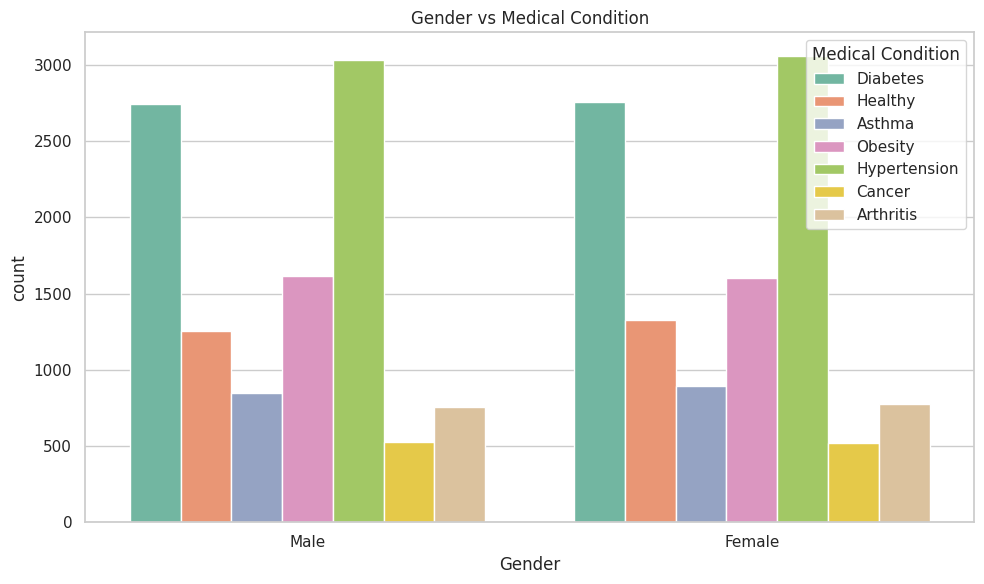

In [122]:
sns.set(style='whitegrid')
plt.figure(figsize=(10, 6))

sns.countplot(x='Gender', hue='Medical Condition', data=data, palette='Set2')
plt.title('Gender vs Medical Condition')

plt.tight_layout()
plt.show()

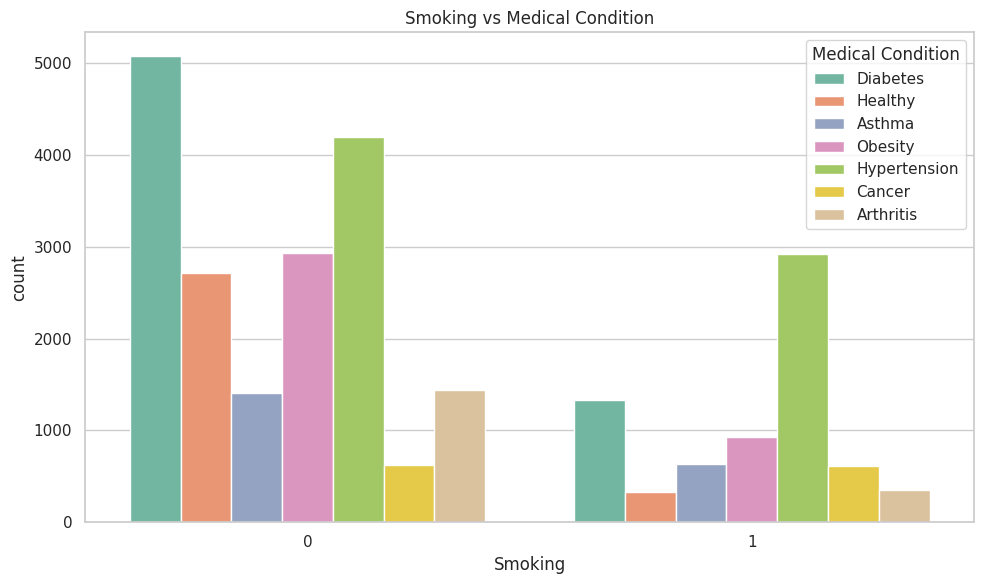

In [123]:
sns.set(style='whitegrid')
plt.figure(figsize=(10, 6))

sns.countplot(x='Smoking', hue='Medical Condition', data=data, palette='Set2')
plt.title('Smoking vs Medical Condition')

plt.tight_layout()
plt.show()

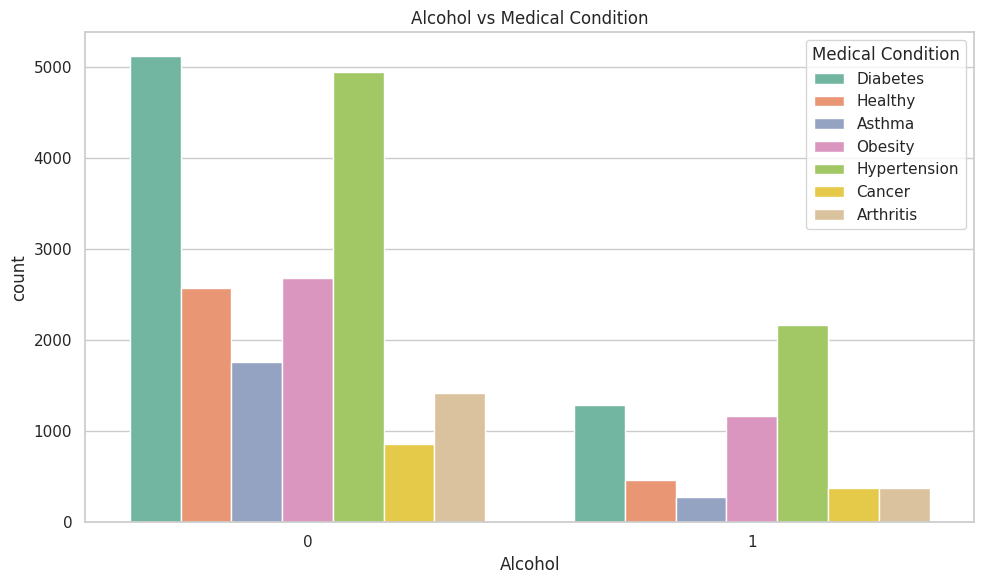

In [124]:
sns.set(style='whitegrid')
plt.figure(figsize=(10, 6))

sns.countplot(x='Alcohol', hue='Medical Condition', data=data, palette='Set2')
plt.title('Alcohol vs Medical Condition')

plt.tight_layout()
plt.show()

/tmp/ipython-input-3689632661.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Medical Condition', y='Age', data=data, palette='Set2')


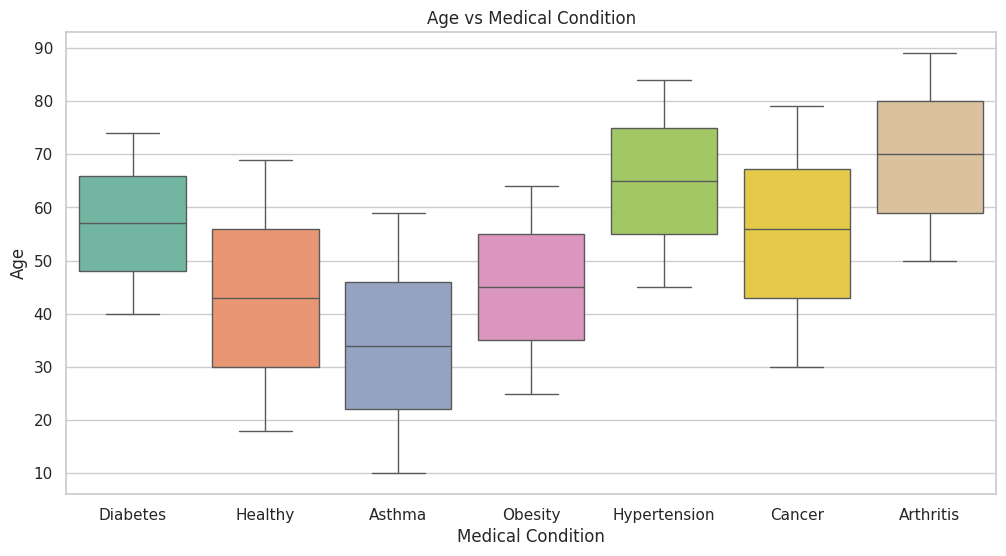

In [125]:
sns.set(style='whitegrid')
plt.figure(figsize=(12, 6))
sns.boxplot(x='Medical Condition', y='Age', data=data, palette='Set2')
plt.title('Age vs Medical Condition')
plt.show()

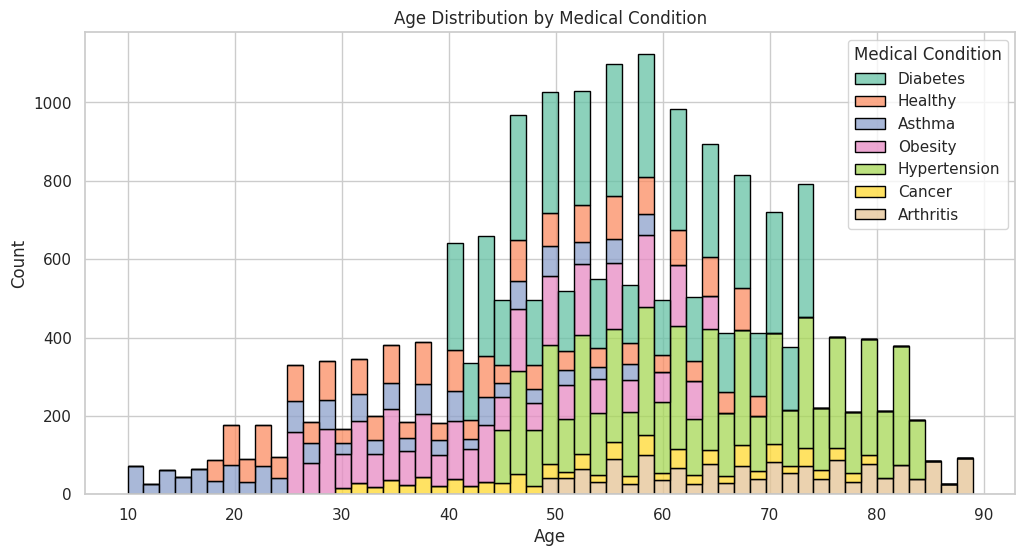

In [126]:
sns.set(style='whitegrid')
plt.figure(figsize=(12, 6))
sns.histplot(x='Age', hue='Medical Condition', data=data, multiple='stack', palette='Set2', edgecolor='black')
plt.title('Age Distribution by Medical Condition')
plt.show()

<Axes: xlabel='Physical Activity', ylabel='Diet Score'>

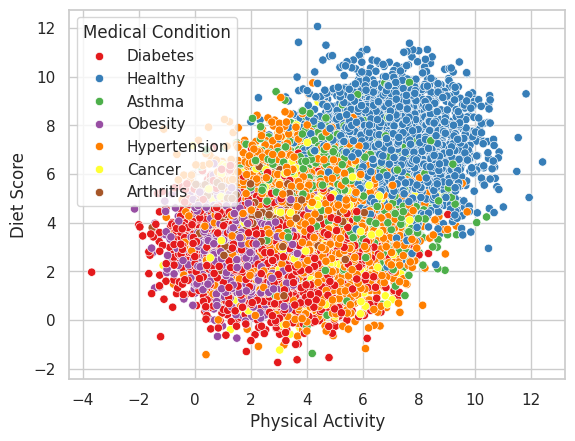

In [127]:
sns.set(style = 'whitegrid')
sns.scatterplot(x='Physical Activity', y='Diet Score', hue='Medical Condition', data=data, palette='Set1')

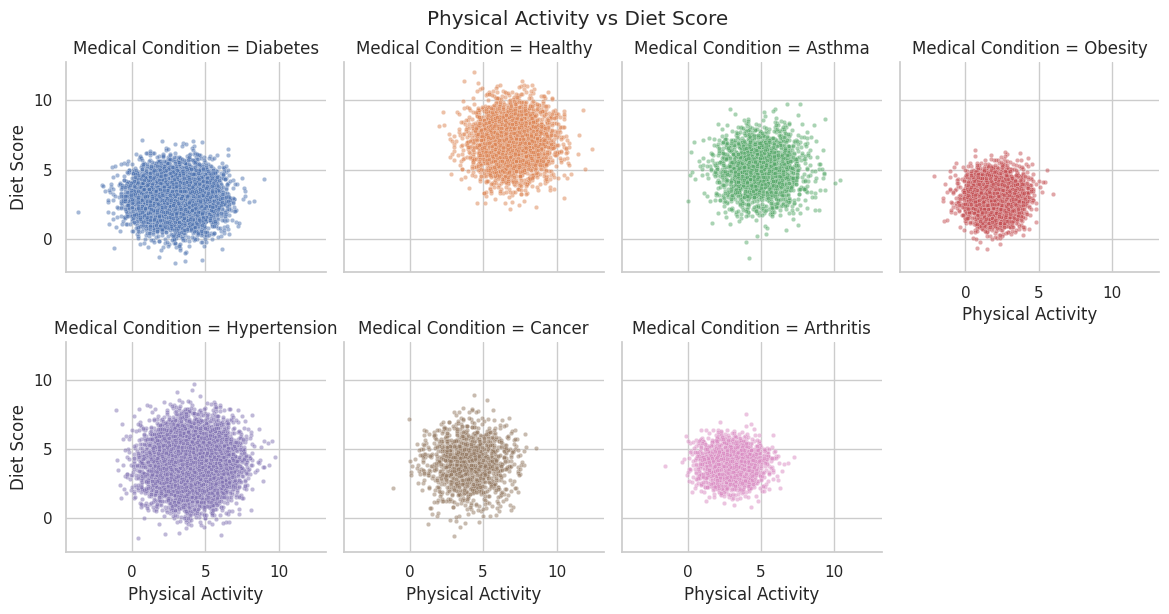

In [128]:
g = sns.FacetGrid(data, col="Medical Condition", col_wrap=4, hue="Medical Condition")
g.map(sns.scatterplot, "Physical Activity", "Diet Score", alpha=0.5, s=10)
plt.suptitle('Physical Activity vs Diet Score', y=1.02)
plt.show()

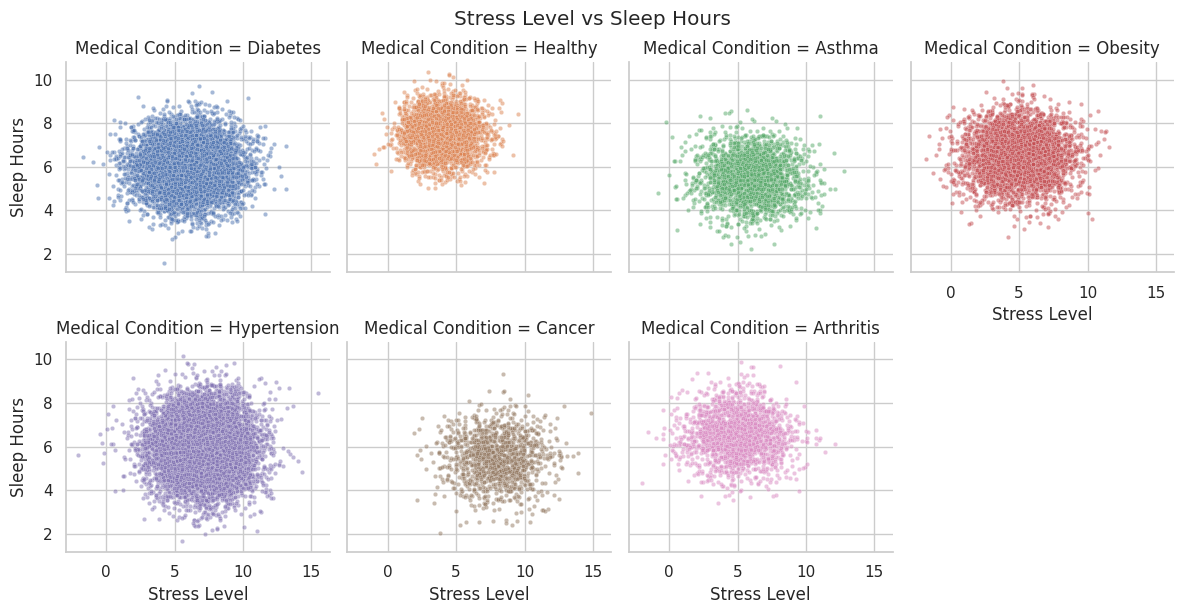

In [129]:
g = sns.FacetGrid(data, col="Medical Condition", col_wrap=4, hue="Medical Condition")
g.map(sns.scatterplot, "Stress Level", "Sleep Hours", alpha=0.5, s=10)
plt.suptitle('Stress Level vs Sleep Hours', y=1.02)
plt.show()

<Axes: xlabel='Cholesterol', ylabel='Diet Score'>

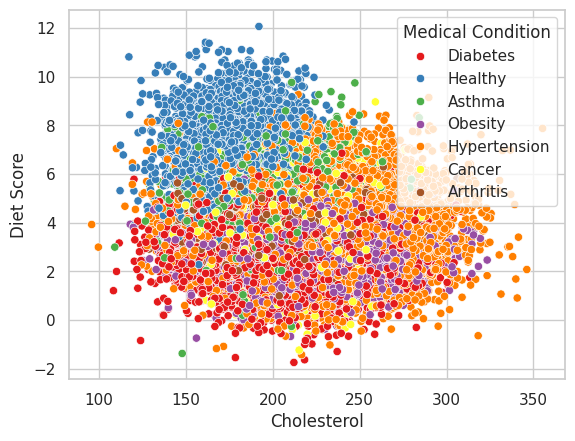

In [130]:
sns.set(style = 'whitegrid')
sns.scatterplot(x='Cholesterol', y='Diet Score', hue='Medical Condition', data=data, palette='Set1')

Key Insights from EDA



*   Chronic conditions, particularly diabetes and hypertension happend in patients aged from 40-45 with means at approximately 57 and 65, respectively. (from graphs 'Age vs Medical Condition' and 'Age Distribution by Medical Condition'
)

*  The healthy group have higher engagement in physical activity and diet quality compared to patients with medical conditions, especially obesity and daibetes group. This highlighting a clear lifestyle deficit that distinguishes these groups from healthy patient. (from the graph 'Physical Activity vs Diet Score')



*   Across all medical conditions, the majority of patients maintain a consistent sleep range at 6-8 hours. However, the healthy group suggests the better sleep behavior and stress management. (from the graph 'Stress Level vs Sleep Hours')
*   Patients diagnosed with the specific medical conditions exhibit distinct behaviors, clustering based on their diet, physical activity, stress levels and sleep hours. (from the graph 'Physical Activity vs Diet Score and 'Stress Level vs Sleep Hours')




### Data Preparation


In [131]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                25500 non-null  float64
 1   Gender             25500 non-null  object 
 2   Medical Condition  25500 non-null  object 
 3   Glucose            25500 non-null  float64
 4   Blood Pressure     25500 non-null  float64
 5   BMI                30000 non-null  float64
 6   Oxygen Saturation  30000 non-null  float64
 7   LengthOfStay       30000 non-null  int64  
 8   Cholesterol        30000 non-null  float64
 9   Triglycerides      30000 non-null  float64
 10  HbA1c              30000 non-null  float64
 11  Smoking            30000 non-null  object 
 12  Alcohol            30000 non-null  object 
 13  Physical Activity  30000 non-null  float64
 14  Diet Score         30000 non-null  float64
 15  Family History     30000 non-null  object 
 16  Stress Level       300

In [132]:
print(f'Missing values in percent:{data.isnull().any(axis=1).mean()*100}')

Missing values in percent:55.48333333333333


According to Medical Condition is the target column, the missing rows are needed to drop.


In [133]:
data.dropna(subset=['Medical Condition'], inplace=True)
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25500 entries, 0 to 29999
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                21679 non-null  float64
 1   Gender             21706 non-null  object 
 2   Medical Condition  25500 non-null  object 
 3   Glucose            21712 non-null  float64
 4   Blood Pressure     21700 non-null  float64
 5   BMI                25500 non-null  float64
 6   Oxygen Saturation  25500 non-null  float64
 7   LengthOfStay       25500 non-null  int64  
 8   Cholesterol        25500 non-null  float64
 9   Triglycerides      25500 non-null  float64
 10  HbA1c              25500 non-null  float64
 11  Smoking            25500 non-null  object 
 12  Alcohol            25500 non-null  object 
 13  Physical Activity  25500 non-null  float64
 14  Diet Score         25500 non-null  float64
 15  Family History     25500 non-null  object 
 16  Stress Level       25500 no

In [134]:
data['missing_age'] = data['Age'].isnull().astype(int)
data['missing_gender'] = data['Gender'].isnull().astype(int)
data['missing_glucose'] = data['Glucose'].isnull().astype(int)
data['missing_blood_pressure'] = data['Blood Pressure'].isnull().astype(int)
data.head()

,Age,Gender,Medical Condition,Glucose,Blood Pressure,BMI,Oxygen Saturation,LengthOfStay,Cholesterol,Triglycerides,...,Alcohol,Physical Activity,Diet Score,Family History,Stress Level,Sleep Hours,missing_age,missing_gender,missing_glucose,missing_blood_pressure
0,46.0,Male,Diabetes,137.04,135.27,28.90,96.04,6,231.88,210.56,...,0,-0.20,3.54,0,5.07,6.05,0,0,0,0
1,22.0,Male,Healthy,71.58,113.27,26.29,97.54,2,165.57,129.41,...,0,8.12,5.90,0,5.87,7.72,0,0,0,0
2,50.0,NaN,Asthma,95.24,NaN,22.53,90.31,2,214.94,165.35,...,0,5.01,4.65,1,3.09,4.82,0,1,0,1
3,57.0,NaN,Obesity,NaN,130.53,38.47,96.60,5,197.71,182.13,...,0,3.16,3.37,0,3.01,5.33,0,1,1,0
4,66.0,Female,Hypertension,95.15,178.17,31.12,94.90,4,259.53,115.85,...,1,3.56,3.40,0,6.38,6.64,0,0,0,0


In [135]:
#Check MCAR for Age
from scipy.stats import chi2_contingency

for column in ['Gender', 'Medical Condition', 'Smoking', 'Alcohol', 'Family History']:
    contingency_table = pd.crosstab(data[column], data['missing_age'])
    chi2, p_value,_,_ = chi2_contingency(contingency_table)
    print(f"Chi-square test for '{column}' and Missingness in 'Age':")
    print(f'Chi-square statistic: {chi2:.3f}')
    print(f'P-value: {p_value:.3f}')
    print("-"*40)

Chi-square test for 'Gender' and Missingness in 'Age':
Chi-square statistic: 0.359
P-value: 0.549
----------------------------------------
Chi-square test for 'Medical Condition' and Missingness in 'Age':
Chi-square statistic: 9.283
P-value: 0.158
----------------------------------------
Chi-square test for 'Smoking' and Missingness in 'Age':
Chi-square statistic: 3.411
P-value: 0.065
----------------------------------------
Chi-square test for 'Alcohol' and Missingness in 'Age':
Chi-square statistic: 0.053
P-value: 0.818
----------------------------------------
Chi-square test for 'Family History' and Missingness in 'Age':
Chi-square statistic: 0.531
P-value: 0.466
----------------------------------------


In [136]:
from scipy import stats
import pandas as pd

missing_data = data[data['Age'].isnull()]
observed_data = data[data['Age'].notnull()]

numeric_columns = data.drop(['Age', 'Medical Condition', 'missing_age'], axis=1).select_dtypes(include=['number']).columns
results = []

for col in numeric_columns:
  missing_group = missing_data[col].dropna()
  observed_group = observed_data[col].dropna()

  test_name = "Mann-Whitney U Test"
  t_stat, p_value = stats.mannwhitneyu(observed_group, missing_group, alternative='two-sided')

  results.append({"Variable":col, "Test Used": test_name, "Statistic": t_stat, "P-value": p_value})

results_df = pd.DataFrame(results)
print(results_df)

for _, row in results_df.iterrows():
  if row['P-value'] < 0.05:
    print(f"The missingness in 'Age' is likely associated with '{row['Variable']}' (P-value: {row['P-value']:.3f}, Test: {row['Test Used']}).")
  else:
    print(f"No evidence of association between missingness in 'Age' and '{row['Variable']}' (P-value: {row['P-value']:.3f}, Test: {row['Test Used']}).")

                  Variable            Test Used   Statistic   P-value
0                  Glucose  Mann-Whitney U Test  29097832.5  0.010524
1           Blood Pressure  Mann-Whitney U Test  29167715.0  0.005679
2                      BMI  Mann-Whitney U Test  41628079.5  0.616121
3        Oxygen Saturation  Mann-Whitney U Test  41582107.5  0.695218
4             LengthOfStay  Mann-Whitney U Test  41175734.5  0.559598
5              Cholesterol  Mann-Whitney U Test  41639813.0  0.596583
6            Triglycerides  Mann-Whitney U Test  41674902.0  0.539907
7                    HbA1c  Mann-Whitney U Test  40871979.5  0.193339
8        Physical Activity  Mann-Whitney U Test  41242406.5  0.676042
9               Diet Score  Mann-Whitney U Test  42011290.5  0.157151
10            Stress Level  Mann-Whitney U Test  41203680.0  0.609930
11             Sleep Hours  Mann-Whitney U Test  42054756.5  0.128934
12          missing_gender  Mann-Whitney U Test  41538916.5  0.639358
13         missing_g

There is a statistical significance to conclude the assumption that the missingness of Age is MCAR.

In [137]:
#Check MCAR for Gender
for column in ['Medical Condition', 'Smoking', 'Alcohol', 'Family History']:
    contingency_table = pd.crosstab(data[column], data['missing_gender'])
    chi2, p_value,_,_ = chi2_contingency(contingency_table)
    print(f"Chi-square test for '{column}' and Missingness in 'Gender':")
    print(f'Chi-square statistic: {chi2:.3f}')
    print(f'P-value: {p_value:.3f}')
    print("-"*40)

Chi-square test for 'Medical Condition' and Missingness in 'Gender':
Chi-square statistic: 12.777
P-value: 0.047
----------------------------------------
Chi-square test for 'Smoking' and Missingness in 'Gender':
Chi-square statistic: 0.335
P-value: 0.563
----------------------------------------
Chi-square test for 'Alcohol' and Missingness in 'Gender':
Chi-square statistic: 0.166
P-value: 0.684
----------------------------------------
Chi-square test for 'Family History' and Missingness in 'Gender':
Chi-square statistic: 0.276
P-value: 0.599
----------------------------------------


In [138]:
missing_data = data[data['Gender'].isnull()]
observed_data = data[data['Gender'].notnull()]

numeric_columns = data.drop(['Gender', 'Medical Condition', 'missing_gender'], axis=1).select_dtypes(include=['number']).columns
results = []

for col in numeric_columns:
  missing_group = missing_data[col].dropna()
  observed_group = observed_data[col].dropna()

  test_name = "Mann-Whitney U Test"
  t_stat, p_value = stats.mannwhitneyu(observed_group, missing_group, alternative='two-sided')

  results.append({"Variable":col, "Test Used": test_name, "Statistic": t_stat, "P-value": p_value})

results_df = pd.DataFrame(results)
print(results_df)

for _, row in results_df.iterrows():
  if row['P-value'] < 0.05:
    print(f"The missingness in 'Gender' is likely associated with '{row['Variable']}' (P-value: {row['P-value']:.3f}, Test: {row['Test Used']}).")
  else:
    print(f"No evidence of association between missingness in 'Gender' and '{row['Variable']}' (P-value: {row['P-value']:.3f}, Test: {row['Test Used']}).")

                  Variable            Test Used   Statistic   P-value
0                      Age  Mann-Whitney U Test  30133757.0  0.359833
1                  Glucose  Mann-Whitney U Test  30209508.5  0.206852
2           Blood Pressure  Mann-Whitney U Test  30352348.0  0.091630
3                      BMI  Mann-Whitney U Test  40803824.5  0.373290
4        Oxygen Saturation  Mann-Whitney U Test  40988847.0  0.654120
5             LengthOfStay  Mann-Whitney U Test  41518970.0  0.407317
6              Cholesterol  Mann-Whitney U Test  41140323.0  0.931502
7            Triglycerides  Mann-Whitney U Test  41055082.5  0.772034
8                    HbA1c  Mann-Whitney U Test  41548143.0  0.374054
9        Physical Activity  Mann-Whitney U Test  42382462.0  0.003936
10              Diet Score  Mann-Whitney U Test  41276795.0  0.810123
11            Stress Level  Mann-Whitney U Test  41318733.0  0.733468
12             Sleep Hours  Mann-Whitney U Test  41307542.0  0.753699
13             missi

There is a statistical significance to conclude the assumption that the missingness of Gender is MAR, associating with Medical Condition and Physical Activity.


In [139]:
#Check MCAR for Glucose
for column in ['Gender', 'Medical Condition', 'Smoking', 'Alcohol', 'Family History']:
    contingency_table = pd.crosstab(data[column], data['missing_glucose'])
    chi2, p_value,_,_ = chi2_contingency(contingency_table)
    print(f"Chi-square test for '{column}' and Missingness in 'Glucose':")
    print(f'Chi-square statistic: {chi2:.3f}')
    print(f'P-value: {p_value:.3f}')
    print("-"*40)

Chi-square test for 'Gender' and Missingness in 'Glucose':
Chi-square statistic: 0.010
P-value: 0.922
----------------------------------------
Chi-square test for 'Medical Condition' and Missingness in 'Glucose':
Chi-square statistic: 9.501
P-value: 0.147
----------------------------------------
Chi-square test for 'Smoking' and Missingness in 'Glucose':
Chi-square statistic: 0.032
P-value: 0.857
----------------------------------------
Chi-square test for 'Alcohol' and Missingness in 'Glucose':
Chi-square statistic: 0.000
P-value: 0.990
----------------------------------------
Chi-square test for 'Family History' and Missingness in 'Glucose':
Chi-square statistic: 0.600
P-value: 0.439
----------------------------------------


In [140]:
missing_data = data[data['Glucose'].isnull()]
observed_data = data[data['Glucose'].notnull()]

numeric_columns = data.drop(['Glucose', 'Medical Condition', 'missing_glucose'], axis=1).select_dtypes(include=['number']).columns
results = []

for col in numeric_columns:
  missing_group = missing_data[col].dropna()
  observed_group = observed_data[col].dropna()

  test_name = "Mann-Whitney U Test"
  t_stat, p_value = stats.mannwhitneyu(observed_group, missing_group, alternative='two-sided')

  results.append({"Variable":col, "Test Used": test_name, "Statistic": t_stat, "P-value": p_value})

results_df = pd.DataFrame(results)
print(results_df)

for _, row in results_df.iterrows():
  if row['P-value'] < 0.05:
    print(f"The missingness in 'Glucose' is likely associated with '{row['Variable']}' (P-value: {row['P-value']:.3f}, Test: {row['Test Used']}).")
  else:
    print(f"No evidence of association between missingness in 'Glucose' and '{row['Variable']}' (P-value: {row['P-value']:.3f}, Test: {row['Test Used']}).")

                  Variable            Test Used   Statistic   P-value
0                      Age  Mann-Whitney U Test  29038551.0  0.068245
1           Blood Pressure  Mann-Whitney U Test  29677132.0  0.278341
2                      BMI  Mann-Whitney U Test  41485278.5  0.385564
3        Oxygen Saturation  Mann-Whitney U Test  40446423.5  0.105829
4             LengthOfStay  Mann-Whitney U Test  41163527.5  0.920979
5              Cholesterol  Mann-Whitney U Test  40357159.5  0.067139
6            Triglycerides  Mann-Whitney U Test  41250362.0  0.759776
7                    HbA1c  Mann-Whitney U Test  41219798.0  0.816020
8        Physical Activity  Mann-Whitney U Test  41233884.5  0.789961
9               Diet Score  Mann-Whitney U Test  41020908.5  0.807951
10            Stress Level  Mann-Whitney U Test  40728257.0  0.345636
11             Sleep Hours  Mann-Whitney U Test  41644176.5  0.212114
12             missing_age  Mann-Whitney U Test  40977252.0  0.574041
13          missing_

There is a statistical significance to conclude the assumption that the missingness of Glucose is MCAR.

Therefore,

In [141]:
#Check MCAR for Bloos Pressure
for column in ['Gender', 'Medical Condition', 'Smoking', 'Alcohol', 'Family History']:
    contingency_table = pd.crosstab(data[column], data['missing_blood_pressure'])
    chi2, p_value,_,_ = chi2_contingency(contingency_table)
    print(f"Chi-square test for '{column}' and Missingness in 'Blood Pressure':")
    print(f'Chi-square statistic: {chi2:.3f}')
    print(f'P-value: {p_value:.3f}')
    print("-"*40)

Chi-square test for 'Gender' and Missingness in 'Blood Pressure':
Chi-square statistic: 0.917
P-value: 0.338
----------------------------------------
Chi-square test for 'Medical Condition' and Missingness in 'Blood Pressure':
Chi-square statistic: 5.865
P-value: 0.438
----------------------------------------
Chi-square test for 'Smoking' and Missingness in 'Blood Pressure':
Chi-square statistic: 0.342
P-value: 0.558
----------------------------------------
Chi-square test for 'Alcohol' and Missingness in 'Blood Pressure':
Chi-square statistic: 0.073
P-value: 0.787
----------------------------------------
Chi-square test for 'Family History' and Missingness in 'Blood Pressure':
Chi-square statistic: 0.008
P-value: 0.927
----------------------------------------


In [142]:
missing_data = data[data['Blood Pressure'].isnull()]
observed_data = data[data['Blood Pressure'].notnull()]

numeric_columns = data.drop(['Glucose', 'Medical Condition', 'missing_blood_pressure'], axis=1).select_dtypes(include=['number']).columns
results = []

for col in numeric_columns:
  missing_group = missing_data[col].dropna()
  observed_group = observed_data[col].dropna()

  test_name = "Mann-Whitney U Test"
  t_stat, p_value = stats.mannwhitneyu(observed_group, missing_group, alternative='two-sided')

  results.append({"Variable":col, "Test Used": test_name, "Statistic": t_stat, "P-value": p_value})

results_df = pd.DataFrame(results)
print(results_df)

for _, row in results_df.iterrows():
  if row['P-value'] < 0.05:
    print(f"The missingness in 'Blood Pressure' is likely associated with '{row['Variable']}' (P-value: {row['P-value']:.3f}, Test: {row['Test Used']}).")
  else:
    print(f"No evidence of association between missingness in 'Blood Pressure' and '{row['Variable']}' (P-value: {row['P-value']:.3f}, Test: {row['Test Used']}).")

             Variable            Test Used   Statistic   P-value
0                 Age  Mann-Whitney U Test  29924976.0  0.906481
1      Blood Pressure  Mann-Whitney U Test         NaN       NaN
2                 BMI  Mann-Whitney U Test  40944303.5  0.494931
3   Oxygen Saturation  Mann-Whitney U Test  40919188.0  0.457794
4        LengthOfStay  Mann-Whitney U Test  41880373.0  0.116047
5         Cholesterol  Mann-Whitney U Test  41299359.0  0.868403
6       Triglycerides  Mann-Whitney U Test  41433703.0  0.626530
7               HbA1c  Mann-Whitney U Test  41507445.0  0.507472
8   Physical Activity  Mann-Whitney U Test  41223860.0  0.988298
9          Diet Score  Mann-Whitney U Test  40897542.0  0.427082
10       Stress Level  Mann-Whitney U Test  40828412.5  0.337390
11        Sleep Hours  Mann-Whitney U Test  41242332.0  0.976499
12        missing_age  Mann-Whitney U Test  41375400.0  0.574214
13     missing_gender  Mann-Whitney U Test  41196600.0  0.897009
14    missing_glucose  Ma

/tmp/ipython-input-2057899765.py:12: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  t_stat, p_value = stats.mannwhitneyu(observed_group, missing_group, alternative='two-sided')


There is a statistical significance to conclude the assumption that the missingness of Blood Pressure is MCAR. Therefore, I impute the missing values with MICE()

In [143]:
data.drop(['missing_age', 'missing_gender', 'missing_glucose', 'missing_blood_pressure'], axis=1, inplace=True)
data

,Age,Gender,Medical Condition,Glucose,Blood Pressure,BMI,Oxygen Saturation,LengthOfStay,Cholesterol,Triglycerides,HbA1c,Smoking,Alcohol,Physical Activity,Diet Score,Family History,Stress Level,Sleep Hours
0,46.0,Male,Diabetes,137.04,135.27,28.90,96.04,6,231.88,210.56,7.61,0,0,-0.20,3.54,0,5.07,6.05
1,22.0,Male,Healthy,71.58,113.27,26.29,97.54,2,165.57,129.41,4.91,0,0,8.12,5.90,0,5.87,7.72
2,50.0,NaN,Asthma,95.24,NaN,22.53,90.31,2,214.94,165.35,5.60,0,0,5.01,4.65,1,3.09,4.82
3,57.0,NaN,Obesity,NaN,130.53,38.47,96.60,5,197.71,182.13,6.92,0,0,3.16,3.37,0,3.01,5.33
4,66.0,Female,Hypertension,95.15,178.17,31.12,94.90,4,259.53,115.85,5.98,0,1,3.56,3.40,0,6.38,6.64
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29994,76.0,NaN,Hypertension,97.17,138.92,25.65,93.99,3,235.65,238.26,6.43,0,0,3.14,3.46,0,6.66,6.10
29995,54.0,Female,Healthy,86.35,127.68,28.30,94.36,1,218.60,152.82,4.85,0,0,9.15,10.35,0,3.65,8.71
29996,41.0,Male,Asthma,89.24,154.37,24.93,96.07,4,198.30,176.81,5.36,1,0,3.34,3.40,0,6.72,2.81
29998,41.0,Male,Diabetes,242.87,152.97,23.57,99.17,3,208.86,224.21,7.59,0,0,3.16,2.59,0,7.10,5.80


In [144]:
gender_category = data['Gender'].astype('category').cat.categories

In [168]:
import statsmodels.api as sm
from statsmodels.imputation.mice import MICEData

data_mice = data.drop(['Medical Condition'], axis=1).copy()
data_mice.columns = (
    data_mice.columns
    .str.strip()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)


#encode categorical
data_mice['Gender'] = data_mice['Gender'].map({'Female': 0, 'Male': 1})
data_mice['Smoking'] = data_mice['Smoking'].astype(float)
data_mice['Alcohol'] = data_mice['Alcohol'].astype(float)
data_mice['Family_History'] = data_mice['Family_History'].astype(float)

mice_data = MICEData(data_mice)

for _ in range(10):
  mice_data.update_all()

imputed_df = mice_data.data

In [169]:
imputed_df.isnull().mean()

,0
Age,0.0
Gender,0.0
Glucose,0.0
Blood_Pressure,0.0
BMI,0.0
Oxygen_Saturation,0.0
LengthOfStay,0.0
Cholesterol,0.0
Triglycerides,0.0
HbA1c,0.0


In [170]:
imputed_df['Gender'] = pd.Categorical.from_codes(
    imputed_df['Gender'].round().astype(int),
    categories=gender_category
)
imputed_df['Smoking'] = imputed_df['Smoking'].astype(object)
imputed_df['Alcohol'] = imputed_df['Alcohol'].astype(object)
imputed_df['Family_History'] = imputed_df['Family_History'].astype(object)

imputed_df['Medical_Condition'] = data['Medical Condition'].values

In [171]:
imputed_df

,Age,Gender,Glucose,Blood_Pressure,BMI,Oxygen_Saturation,LengthOfStay,Cholesterol,Triglycerides,HbA1c,Smoking,Alcohol,Physical_Activity,Diet_Score,Family_History,Stress_Level,Sleep_Hours,Medical_Condition
0,46.0,Male,137.04,135.27,28.90,96.04,6,231.88,210.56,7.61,0.0,0.0,-0.20,3.54,0.0,5.07,6.05,Diabetes
1,22.0,Male,71.58,113.27,26.29,97.54,2,165.57,129.41,4.91,0.0,0.0,8.12,5.90,0.0,5.87,7.72,Healthy
2,50.0,Male,95.24,131.72,22.53,90.31,2,214.94,165.35,5.60,0.0,0.0,5.01,4.65,1.0,3.09,4.82,Asthma
3,57.0,Female,88.15,130.53,38.47,96.60,5,197.71,182.13,6.92,0.0,0.0,3.16,3.37,0.0,3.01,5.33,Obesity
4,66.0,Female,95.15,178.17,31.12,94.90,4,259.53,115.85,5.98,0.0,1.0,3.56,3.40,0.0,6.38,6.64,Hypertension
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25495,76.0,Female,97.17,138.92,25.65,93.99,3,235.65,238.26,6.43,0.0,0.0,3.14,3.46,0.0,6.66,6.10,Hypertension
25496,54.0,Female,86.35,127.68,28.30,94.36,1,218.60,152.82,4.85,0.0,0.0,9.15,10.35,0.0,3.65,8.71,Healthy
25497,41.0,Male,89.24,154.37,24.93,96.07,4,198.30,176.81,5.36,1.0,0.0,3.34,3.40,0.0,6.72,2.81,Asthma
25498,41.0,Male,242.87,152.97,23.57,99.17,3,208.86,224.21,7.59,0.0,0.0,3.16,2.59,0.0,7.10,5.80,Diabetes


<Axes: title={'center': 'Age (Imputed)'}, xlabel='Age', ylabel='Frequency'>

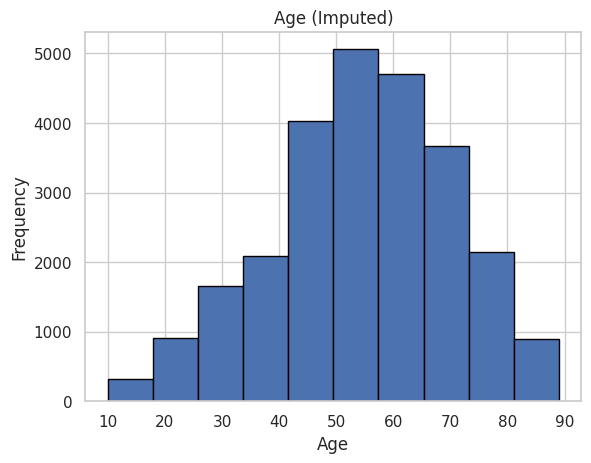

In [172]:
imputed_df['Age'].plot(title='Age (Imputed)', kind='hist', xlabel='Age', ylabel='Frequency', edgecolor='black')

<Axes: title={'center': 'Gender (Imputed)'}, xlabel='Gender', ylabel='Frequency'>

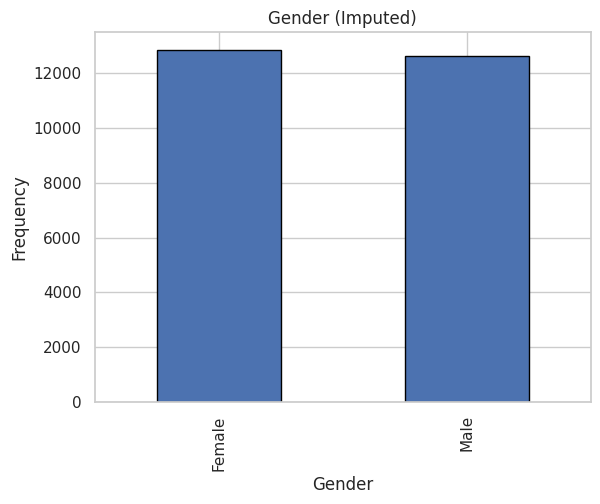

In [173]:
imputed_df['Gender'].value_counts().plot(title='Gender (Imputed)', kind='bar', xlabel='Gender', ylabel='Frequency', edgecolor='black')

<Axes: title={'center': 'Glucose (Imputed)'}, xlabel='Glucose', ylabel='Frequency'>

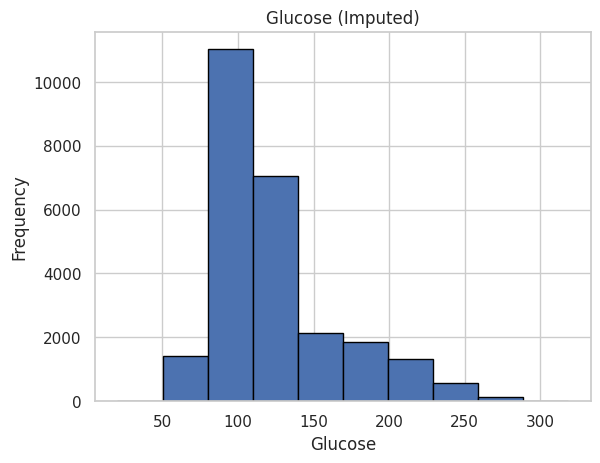

In [174]:
imputed_df['Glucose'].plot(title='Glucose (Imputed)', kind='hist', xlabel='Glucose', ylabel='Frequency', edgecolor='black')

<Axes: title={'center': 'Blood Pressure (Imputed)'}, xlabel='Blood Pressure', ylabel='Frequency'>

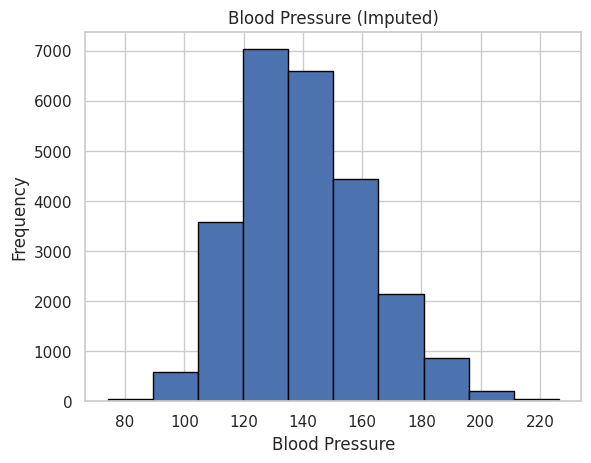

In [175]:
imputed_df['Blood_Pressure'].plot(title='Blood Pressure (Imputed)', kind='hist', xlabel='Blood Pressure', ylabel='Frequency', edgecolor='black')